In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [ ]:
from scipy.spatial import cKDTree

class Bolshoi_HaloCatalogue:

    def __init__(self,filepath,
        npart_thresh=100,
        xoff_thresh=0.07,
        spin_thresh=0.07,
        isolation_factor=3):
 
        self.filepath         = filepath
        self.npart_thresh     = npart_thresh
        self.mass_thresh      = npart_thresh * (1.55e8)           # Msun — for reference
        self.log_mass_thresh  = np.log10(npart_thresh * (1.55e8)) # log10 Msun — for comparisons
        self.xoff_thresh      = xoff_thresh
        self.spin_thresh      = spin_thresh
        self.isolation_factor = isolation_factor

        self._load()
        self._compute_subhalo_order()
        self._relaxation_cut()
        self._isolation_cut()
        self._print_counts()

    def _load(self):

        COLS = [
            "host_id", "logMh", "ch", "a_50h",
            "Xoff_h", "Spin_h", "Spin_Bullock_h", "ch_K",
            "x_h", "y_h", "z_h", "R_vir", "h_pid", "h_upid",
            "id", "pid", "upid", "log10Mvir", "Rvir", "rs", "vrms", "scale_of_last_MM",
            "vmax", "x", "y", "z", "vx", "vy", "vz",
            "Jx", "Jy", "Jz", "Spin", "Tidal_Force", "Tidal_ID",
            "Mmvir_all", "M200b", "M200c", "M500c",
            "Xoff", "Voff", "Spin_Bullock",
            "b_to_a", "c_to_a",
            "Ax", "Ay", "Az", "T_by_U",
            "M_pe_Behroozi", "M_pe_Diemer",
            "Macc", "Mpeak", "Vacc", "Vpeak", "Halfmass_Scale",
            "Acc_Rate_Inst", "Acc_Rate_100Myr", "Acc_Rate_1Tdyn",
            "Acc_Rate_2Tdyn", "Acc_Rate_Mpeak",
            "Mpeak_Scale", "Acc_Scale", "First_Acc_Scale",
            "First_Acc_Mvir", "First_Acc_Vmax", "Vmax_at_Mpeak",
            "Tidal_Force_Tdyn"
        ]

        raw        = np.loadtxt(self.filepath)
        self._df   = pd.DataFrame(raw, columns=COLS)

    def _compute_subhalo_order(self, max_order=5):
        """
        Vectorized parent-chain hop-count: assigns each row an integer 'order'
        counting how many pid-hops separate it from its top-level host (upid).
        order = 0        -> host itself (upid == -1)
        order = 1        -> direct child of the host (pid == upid)
        order = 2,3,...  -> each additional intermediate parent
        Rows whose chain doesn't resolve within max_order hops (broken/orphaned
        links, e.g. parent pruned from this snapshot) are left at max_order as
        a safe upper-bound bucket (folds into the k>=3 bucket downstream).
        """
        ids   = self._df["id"].values
        pids  = self._df["pid"].values
        upids = self._df["upid"].values

        id_to_pid = pd.Series(pids, index=ids)

        order = np.zeros(len(self._df), dtype=int)
        is_host = (upids == -1)
        order[is_host] = 0

        is_sub = ~is_host
        order[is_sub] = 1
        current = pids.copy()

        unresolved = is_sub & (current != upids)

        hop = 2
        while unresolved.any() and hop <= max_order:
            next_parent = pd.Series(current[unresolved]).map(id_to_pid).values
            broken = pd.isna(next_parent)
            next_parent = np.where(broken, current[unresolved], next_parent)

            current[unresolved] = next_parent
            order[unresolved] = hop

            still_unresolved = unresolved.copy()
            still_unresolved[unresolved] = (current[unresolved] != upids[unresolved]) & (~broken)
            unresolved = still_unresolved
            hop += 1

        self._df["order"] = order

    def _relaxation_cut(self):
        host_props = (
            self._df
            .groupby("host_id")[["Xoff_h", "Spin_h", "R_vir"]]
            .mean()
            .reset_index()
        )
        relaxed_ids = host_props[
            (host_props["Xoff_h"] / host_props["R_vir"] <= self.xoff_thresh) &
            (host_props["Spin_h"] <= self.spin_thresh)
        ]["host_id"].values

        self._df_relaxed = self._df[self._df["host_id"].isin(relaxed_ids)]

    def _isolation_cut(self):
        host_relaxed = (
            self._df_relaxed
            .groupby("host_id")[["x_h", "y_h", "z_h", "R_vir", "logMh"]]
            .mean()
            .reset_index()
        )

        coords   = host_relaxed[["x_h", "y_h", "z_h"]].values
        masses   = host_relaxed["logMh"].values
        r_virial = host_relaxed["R_vir"].values / 1000.0   # kpc/h -> Mpc/h

        tree     = cKDTree(coords)
        isolated = np.ones(len(host_relaxed), dtype=bool)

        # Upper bound search radius: no more massive halo can be further than
        # isolation_factor * max(Rvir) away
        max_search_r = self.isolation_factor * r_virial.max()

        for i in range(len(host_relaxed)):
            # Query all neighbours within the maximum possible isolation radius
            neighbours = tree.query_ball_point(coords[i], r=max_search_r)
            for j in neighbours:
                if j == i:
                    continue
                if masses[j] >= masses[i]:
                    # Use the MORE MASSIVE halo's (j's) Rvir to define isolation
                    isolation_radius = self.isolation_factor * r_virial[j]
                    dist = np.linalg.norm(coords[i] - coords[j])
                    if dist < isolation_radius:
                        isolated[i] = False
                        break

        isolated_ids      = host_relaxed[isolated]["host_id"].values
        self._df_isolated = self._df_relaxed[self._df_relaxed["host_id"].isin(isolated_ids)]

    def _print_counts(self):
        n_raw     = self._df["host_id"].unique().shape[0]
        n_relaxed = self._df_relaxed["host_id"].unique().shape[0]
        n_final   = self._df_isolated["host_id"].unique().shape[0]
        print(
            f"Hosts: total={n_raw}  "
            f"after relaxation={n_relaxed} ({100*n_relaxed/n_raw:.1f}%)  "
            f"after isolation={n_final} ({100*n_final/n_raw:.1f}%)"
        )

    def _select_subset1(self, subset):
        """
        Given a host's subhalo subset, return the bound subhalo population:
        log10Mvir >= mass threshold AND within Rvir of the host center.
        """
        x_h     = subset["x_h"].mean()
        y_h     = subset["y_h"].mean()
        z_h     = subset["z_h"].mean()
        R_vir_i = subset["R_vir"].mean()

        dr = np.sqrt(
            (subset["x"] - x_h)**2 +
            (subset["y"] - y_h)**2 +
            (subset["z"] - z_h)**2
        )

        return subset[(subset["log10Mvir"] >= self.log_mass_thresh) & (dr <= R_vir_i)]

    def compute_shmf(self, sample):
        """
        Compute the z=0 subhalo mass function per host halo, split by
        subhalo order (k = all, 1, 2, 3+).

        Returns a dict with:
            host_id           : (n_host,)              host halo IDs
            logMvir           : (n_host,)               host log10(Mvir)
            log10Mvir_sub_all : (n_host, n_sub_max_all)  NaN-padded, all subhalos
            log10Mvir_sub_k1  : (n_host, n_sub_max_k1)   NaN-padded, order-1 subhalos
            log10Mvir_sub_k2  : (n_host, n_sub_max_k2)   NaN-padded, order-2 subhalos
            log10Mvir_sub_k3p : (n_host, n_sub_max_k3p)  NaN-padded, order>=3 subhalos
        """
        if sample == "isolated":
            host_id_unique = np.sort(self._df_isolated["host_id"].unique())
            groups = self._df_isolated.groupby("host_id")
        elif sample == "relaxed":
            host_id_unique = np.sort(self._df_relaxed["host_id"].unique())
            groups = self._df_relaxed.groupby("host_id")
        elif sample == "all":
            host_id_unique = np.sort(self._df["host_id"].unique())
            groups = self._df.groupby("host_id")
        else:
            raise ValueError(f"Unknown sample type: {sample}")

        n_host = len(host_id_unique)

        host_logMvir = np.zeros(n_host)

        sub_mass_lists = {
            "all": [],
            1:     [],
            2:     [],
            3:     [],   # k = 3+ bucket
        }

        for i, hid in enumerate(host_id_unique):
            subset  = groups.get_group(hid)
            subset1 = self._select_subset1(subset)

            host_logMvir[i] = subset["logMh"].mean()

            order_vals = subset1["order"].values
            masses     = subset1["log10Mvir"].values

            sub_mass_lists["all"].append(masses)
            sub_mass_lists[1].append(masses[order_vals == 1])
            sub_mass_lists[2].append(masses[order_vals == 2])
            sub_mass_lists[3].append(masses[order_vals >= 3])

        def _pad(mass_list):
            n_sub_max = max((len(a) for a in mass_list), default=0)
            padded = np.full((n_host, n_sub_max), np.nan)
            for i, arr in enumerate(mass_list):
                padded[i, :len(arr)] = arr
            return padded

        return {
            "host_id":           host_id_unique,
            "logMvir":           host_logMvir,
            "logMsub_all": _pad(sub_mass_lists["all"]),
            "logMsub_k1":  _pad(sub_mass_lists[1]),
            "logMsub_k2":  _pad(sub_mass_lists[2]),
            "logMsub_k3p": _pad(sub_mass_lists[3]),
        }

    def _build_host_table(self, sample):

        if sample == "isolated":
            host_id_unique = np.sort(self._df_isolated["host_id"].unique())
            groups = self._df_isolated.groupby("host_id")
        if sample == "relaxed":
            host_id_unique = np.sort(self._df_relaxed["host_id"].unique())
            groups = self._df_relaxed.groupby("host_id")
        if sample == "all":
            host_id_unique = np.sort(self._df["host_id"].unique())
            groups = self._df.groupby("host_id")

        n_host = len(host_id_unique)

        logMvir    = np.zeros(n_host)
        log1pz50   = np.zeros(n_host)
        logc       = np.zeros(n_host)

        Nsub       = np.zeros(n_host)   # k = all
        logNsub    = np.zeros(n_host)
        fsub       = np.zeros(n_host)
        logfsub    = np.zeros(n_host)
        MMs        = np.zeros(n_host)
        logMMs     = np.zeros(n_host)

        # order-resolved arrays: k = 1, 2, 3+
        Nsub_k    = {1: np.zeros(n_host), 2: np.zeros(n_host), 3: np.zeros(n_host)}
        logNsub_k = {1: np.zeros(n_host), 2: np.zeros(n_host), 3: np.zeros(n_host)}
        fsub_k    = {1: np.zeros(n_host), 2: np.zeros(n_host), 3: np.zeros(n_host)}
        logfsub_k = {1: np.zeros(n_host), 2: np.zeros(n_host), 3: np.zeros(n_host)}
        MMs_k     = {1: np.zeros(n_host), 2: np.zeros(n_host), 3: np.zeros(n_host)}
        logMMs_k  = {1: np.zeros(n_host), 2: np.zeros(n_host), 3: np.zeros(n_host)}

        for i, hid in enumerate(host_id_unique):
            subset   = groups.get_group(hid)

            logMh_i  = subset["logMh"].mean()
            c_h_i    = subset["ch_K"].mean()
            a_half_i = subset["a_50h"].mean()

            subset1  = self._select_subset1(subset)
            host_mass = 10**logMh_i

            z50 = (1.0 / a_half_i) - 1.0
            logMvir[i]  = logMh_i
            log1pz50[i] = np.log10(1.0 + z50)
            logc[i]     = np.log10(c_h_i)

            # ---- k = all (unchanged from before) ----
            Nsub_i = len(subset1)
            Nsub[i]    = Nsub_i
            logNsub[i] = np.log10(Nsub_i)
            if Nsub_i > 0:
                fsub[i] = np.sum(10**subset1["log10Mvir"]) / host_mass
                MMs[i]  = (10**subset1["log10Mvir"].max()) / host_mass
            logfsub[i] = np.log10(fsub[i])
            logMMs[i]  = np.log10(MMs[i])

            # ---- order-resolved: k = 1, 2, 3+ ----
            order_vals = subset1["order"].values
            for k in (1, 2, 3):
                sel_mask = (order_vals == k) if k < 3 else (order_vals >= 3)
                sel      = subset1[sel_mask]
                n_k      = len(sel)

                Nsub_k[k][i]    = n_k
                logNsub_k[k][i] = np.log10(n_k)

                if n_k > 0:
                    fsub_k[k][i] = np.sum(10**sel["log10Mvir"]) / host_mass
                    MMs_k[k][i]  = (10**sel["log10Mvir"].max()) / host_mass
                logfsub_k[k][i] = np.log10(fsub_k[k][i])
                logMMs_k[k][i]  = np.log10(MMs_k[k][i])

        host_table = pd.DataFrame({
            "logMvir":  logMvir,
            "log1pz50": log1pz50,
            "logc":     logc,

            "Nsub":     Nsub,      # k = all
            "logNsub":  logNsub,
            "fsub":     fsub,
            "logfsub":  logfsub,
            "MMs":      MMs,
            "logMMs":   logMMs,

            "Nsub_k1":    Nsub_k[1],
            "logNsub_k1": logNsub_k[1],
            "fsub_k1":    fsub_k[1],
            "logfsub_k1": logfsub_k[1],
            "MMs_k1":     MMs_k[1],
            "logMMs_k1":  logMMs_k[1],

            "Nsub_k2":    Nsub_k[2],
            "logNsub_k2": logNsub_k[2],
            "fsub_k2":    fsub_k[2],
            "logfsub_k2": logfsub_k[2],
            "MMs_k2":     MMs_k[2],
            "logMMs_k2":  logMMs_k[2],

            "Nsub_k3p":    Nsub_k[3],
            "logNsub_k3p": logNsub_k[3],
            "fsub_k3p":    fsub_k[3],
            "logfsub_k3p": logfsub_k[3],
            "MMs_k3p":     MMs_k[3],
            "logMMs_k3p":  logMMs_k[3],
        }).replace([np.inf, -np.inf], np.nan)

        return host_table

In [5]:
cat = Bolshoi_HaloCatalogue_test(
        "../../../misc/ForSebastian/N_AB_sub_BolPlanck.dat",
        npart_thresh=500,
        xoff_thresh=0.07,
        spin_thresh=0.07,
        isolation_factor=3)

Hosts: total=95737  after relaxation=72110 (75.3%)  after isolation=62066 (64.8%)


In [ ]:
boltab = cat._build_host_table(sample="relaxed")
shmf_tab = cat.compute_shmf(sample="relaxed")


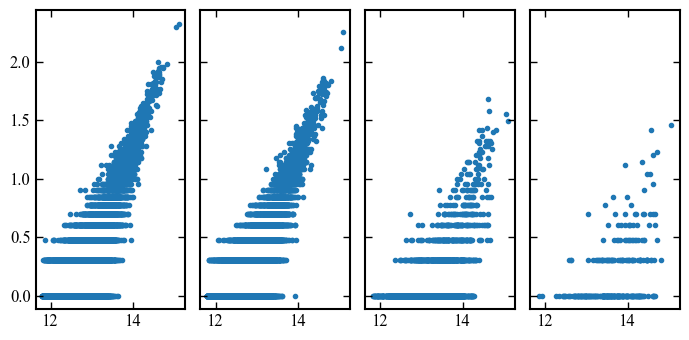

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(double_textwidth, single_textwidth), sharex=True, sharey=True)

axes[0].scatter(boltab["logMvir"], boltab["logNsub"], marker=".")

axes[1].scatter(boltab["logMvir"], boltab["logNsub_k1"], marker=".")

axes[2].scatter(boltab["logMvir"], boltab["logNsub_k2"], marker=".")

axes[3].scatter(boltab["logMvir"], boltab["logNsub_k3p"], marker=".")

plt.tight_layout()
plt.show()

In [10]:
def count_bol(vals, mass_bins):
    bolhist = np.apply_along_axis(jsm_stats.count_straight, 1, vals, mass_bins)
    return np.average(bolhist, axis=0)

In [29]:
binz = np.logspace(np.log10(7.75e10), 14, 20)
bin_edges = (binz[:-1] + binz[1:]) / 2
splitMvir = np.linspace(12.6, 14.0, 8)
mvir_label = np.array([12.6, 12.8, 13.0, 13.2, 13.4, 13.6, 13.8, 14.0])
xvals = np.log10(bin_edges)

i = 7
print(mvir_label[i])
mass_cut_i = (splitMvir[i]-0.1 < shmf_tab["logMvir"]) & (shmf_tab["logMvir"] < splitMvir[i]+0.1)

14.0


In [34]:
test_all = 10**shmf_tab["logMsub_all"][mass_cut_i]

test_k1 = 10**shmf_tab["logMsub_k1"][mass_cut_i]

test_k2 = 10**shmf_tab["logMsub_k2"][mass_cut_i]

test_k3 = 10**shmf_tab["logMsub_k3p"][mass_cut_i]

In [35]:
bolcount_all = count_bol(test_all, binz)

bolcount_k1 = count_bol(test_k1, binz)

bolcount_k2 = count_bol(test_k2, binz)

bolcount_k3 = count_bol(test_k3, binz)

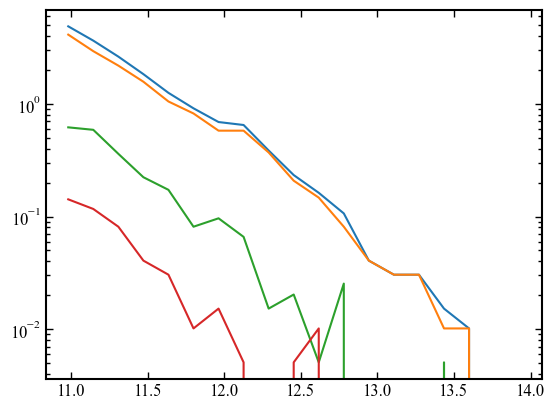

In [39]:
plt.plot(xvals, bolcount_all)
plt.plot(xvals, bolcount_k1)
plt.plot(xvals, bolcount_k2)
plt.plot(xvals, bolcount_k3)

plt.yscale("log")